In [1]:
# Cell 0 
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
#shouldd appearr [PhysicalDevice(name='/physical_device:GPU:0')]

2026-05-12 08:11:28.318851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778573488.472560      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778573488.519542      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778573488.889641      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778573488.889708      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778573488.889715      56 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
#   CELL 1 — IMPORTS + DATA LOADING 
# ============================================================
!pip install tensorflow-datasets -q

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# ── Load Data ────────────────────────────────────────────────
(ds_train_full, ds_test), info = tfds.load(
    'cifar10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)
class_names = info.features['label'].names
IMG_SIZE    = 224
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

# ── Preprocessing Functions ──────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

def preprocess_effnet(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image, training=True)
    image = efficientnet_preprocess(image)
    label = tf.one_hot(label, depth=10)
    return image, label

def preprocess_effnet_val(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = efficientnet_preprocess(image)
    label = tf.one_hot(label, depth=10)
    return image, label

def preprocess_resnet(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = resnet_preprocess(image)
    label = tf.one_hot(label, depth=10)
    return image, label

# ── Datasets for EfficientNet ────────────────────────────────
ds_train_eff = (ds_train_full.take(45000)
                .map(preprocess_effnet, num_parallel_calls=AUTOTUNE)
                .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_val_eff   = (ds_train_full.skip(45000).take(5000)
                .map(preprocess_effnet_val, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_test_eff  = (ds_test
                .map(preprocess_effnet_val, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# ── Datasets for ResNet50 ────────────────────────────────────
ds_train_res = (ds_train_full.take(45000)
                .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
                .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_val_res   = (ds_train_full.skip(45000).take(5000)
                .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_test_res  = (ds_test
                .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# ── Helper Functions ─────────────────────────────────────────
def extract_features(dataset, model, num_samples):
    features, labels = [], []
    count = 0
    for images, lbls in dataset:
        feats = model(images, training=False)
        features.append(feats.numpy())
        labels.append(np.argmax(lbls.numpy(), axis=1))
        count += len(images)
        if count >= num_samples:
            break
    return np.vstack(features)[:num_samples], np.concatenate(labels)[:num_samples]

def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def plot_two_phase_curves(h1, h2, model_name, filename):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    split    = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curves — {model_name}',
                 fontsize=13, fontweight='bold')

    for ax, train, val, title in [
        (axes[0], acc, val_acc, 'Accuracy'),
        (axes[1], loss, val_loss, 'Loss')
    ]:
        ax.plot(train, label='Train', color='blue', linewidth=2)
        ax.plot(val,   label='Val',   color='orange', linewidth=2)
        ax.axvline(x=split, color='red', linestyle='--',
                   label='Fine-tuning starts')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def save_results_csv(model_name, approach,
                     acc, prec, rec, f1, train_time, filename):
    df = pd.DataFrame([{
        'Model'    : model_name,
        'Approach' : approach,
        'Accuracy' : round(acc*100, 2),
        'Precision': round(prec*100, 2),
        'Recall'   : round(rec*100, 2),
        'F1_Score' : round(f1*100, 2),
        'Time_sec' : round(train_time, 1)
    }])
    df.to_csv(filename, index=False)
    print(f"  ✅ Results saved: {filename}")
    print(df.to_string(index=False))

print("✅ Cell 1 Complete — Data & Functions Ready!")
print(f"  EfficientNet datasets: train={len(ds_train_eff)} batches")
print(f"  ResNet50 datasets    : train={len(ds_train_res)} batches")

# ============================================================
#   DATASET SUMMARY & SPECIFICATIONS 
# ============================================================
print("\n" + "="*60)
print("   DATASET METADATA & TECHNICAL SPECIFICATIONS")
print("="*60)

# 1) Dataset Metadata
print(f"1) Source         : CIFAR-10 (via TensorFlow Datasets)")
print(f"   Problem Domain : Multi-class Image Classification")
print(f"   Total Samples  : {info.splits['train'].num_examples + info.splits['test'].num_examples} (N)")

# 2) Technical Specifications
print(f"\n2) Resolution     : {IMG_SIZE} x {IMG_SIZE} (Upscaled for Transfer Learning)")
print(f"   Color Channels : RGB (3 channels)")
print(f"   Total Classes  : {info.features['label'].num_classes} ({', '.join(class_names[:3])}...)")

# 3) Data Preprocessing
print(f"\n3) Preprocessing  : Resized to {IMG_SIZE}x{IMG_SIZE}, Cast to Float32,")
print(f"   Normalization  : Application-specific (Scaling pixels to [-1, 1] or [0, 1])")

# 4) Data Augmentation
print(f"\n4) Augmentation   : Horizontal Flip, Rotation (0.1), Zoom (0.2), Brightness/Contrast")
print(f"   Justification  : Used to prevent overfitting and improve generalization by")
print(f"                    simulating different camera angles and lighting conditions,")
print(f"                    which is crucial for the small 32x32 original CIFAR-10 images.")

# 5) Data Splitting
train_count = 45000
val_count   = 5000
test_count  = 10000
print(f"\n5) Data Splitting : Training: {train_count} | Validation: {val_count} | Testing: {test_count}")
print(f"   Split Ratio    : 90% Train/Val (45k/5k) and 10% Test (10k)")
print("="*60)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1778573562.051248      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778573562.053819      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shuffling /root/tensorflow_datasets/cifar10/incomplete.HAKTFU_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.HAKTFU_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
✅ Cell 1 Complete — Data & Functions Ready!
  EfficientNet datasets: train=1407 batches
  ResNet50 datasets    : train=1407 batches

   DATASET METADATA & TECHNICAL SPECIFICATIONS
1) Source         : CIFAR-10 (via TensorFlow Datasets)
   Problem Domain : Multi-class Image Classification
   Total Samples  : 60000 (N)

2) Resolution     : 224 x 224 (Upscaled for Transfer Learning)
   Color Channels : RGB (3 channels)
   Total Classes  : 10 (airplane, automobile, bird...)

3) Preprocessing  : Resized to 224x224, Cast to Float32,
   Normalization  : Application-specific (Scaling pixels to [-1, 1] or [0, 1])

4) Augmentation   : Horizontal Flip, Rotation (0.1), Zoom (0.2), Brightness/Contrast
   Justification  : Used to prevent overfitting and improve generalization by
                    simulating different camera angles and lighting conditions,
                    wh

   MODEL: EfficientNet-B0

── Approach 1: EfficientNet-B0 + SVM ──

  Note: Using 10,000 train / 5,000 test subset for SVM.
  Reason: SVM has high complexity on 1280-dim vectors.
  This subset is statistically representative.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Extracting features...


I0000 00:00:1778573639.318399      56 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Feature shape: train=(10000, 1280), test=(5000, 1280)
  Training SVM (linear kernel)...

  Accuracy : 85.26%
  Precision: 85.51%
  Recall   : 85.26%
  F1-Score : 85.34%
  Time     : 189.3s

  Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.89      0.88       520
  automobile       0.93      0.89      0.91       493
        bird       0.77      0.82      0.79       478
         cat       0.72      0.76      0.74       517
        deer       0.83      0.82      0.83       476
         dog       0.81      0.81      0.81       524
        frog       0.91      0.85      0.88       507
       horse       0.93      0.88      0.90       496
        ship       0.92      0.91      0.91       506
       truck       0.87      0.89      0.88       483

    accuracy                           0.85      5000
   macro avg       0.86      0.85      0.85      5000
weighted avg       0.86      0.85      0.85      5000



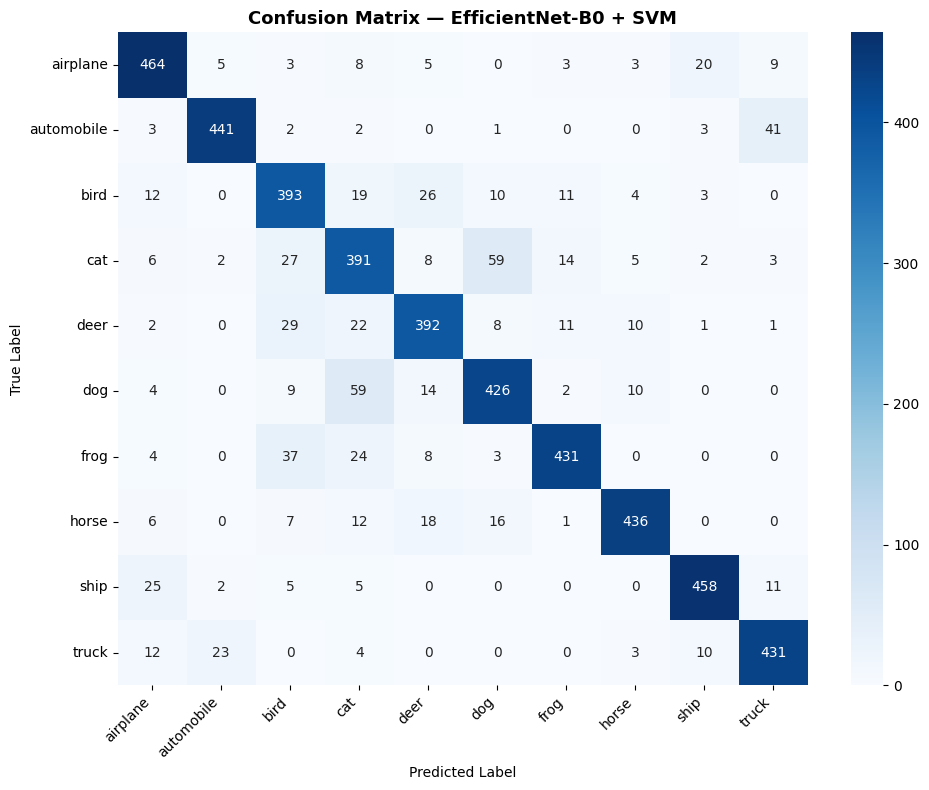

  ✅ Results saved: results_eff_svm.csv
          Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
EfficientNet-B0 Approach1_SVM     85.26      85.51   85.26     85.34     189.3

── Approach 2: EfficientNet-B0 End-to-End ──

  Phase 1: Training head only (frozen base)...
Epoch 1/10


I0000 00:00:1778573839.314734     138 service.cc:152] XLA service 0x7ca4a4004fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778573839.314790     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778573839.314796     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-05-12 08:17:27.995320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:17:28.139824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:17:28.485126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6923 - loss: 0.8903

2026-05-12 08:21:41.369613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:21:41.506495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:21:41.813796: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:21:41.954341: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 08:21:42.737307: E external/local_xla/xla/stream_

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 304s 194ms/step - accuracy: 0.6924 - loss: 0.8899 - val_accuracy: 0.8906 - val_loss: 0.3251 - learning_rate: 0.0010
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 248s 173ms/step - accuracy: 0.7858 - loss: 0.6156 - val_accuracy: 0.8950 - val_loss: 0.3073 - learning_rate: 0.0010
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 247s 173ms/step - accuracy: 0.8014 - loss: 0.5782 - val_accuracy: 0.8976 - val_loss: 0.2983 - learning_rate: 0.0010
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 248s 173ms/step - accuracy: 0.8069 - loss: 0.5644 - val_accuracy: 0.9012 - val_loss: 0.2956 - learning_rate: 0.0010
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 249s 174ms/step - accuracy: 0.8091 - loss: 0.5509 - val_accuracy: 0.9020 - val_loss: 0.2748 - learning_rate: 0.0010
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 249s 173ms/step - accuracy: 0.8152 - loss: 0.5278 - val_accuracy: 0.9084 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 245s 171ms/step - acc

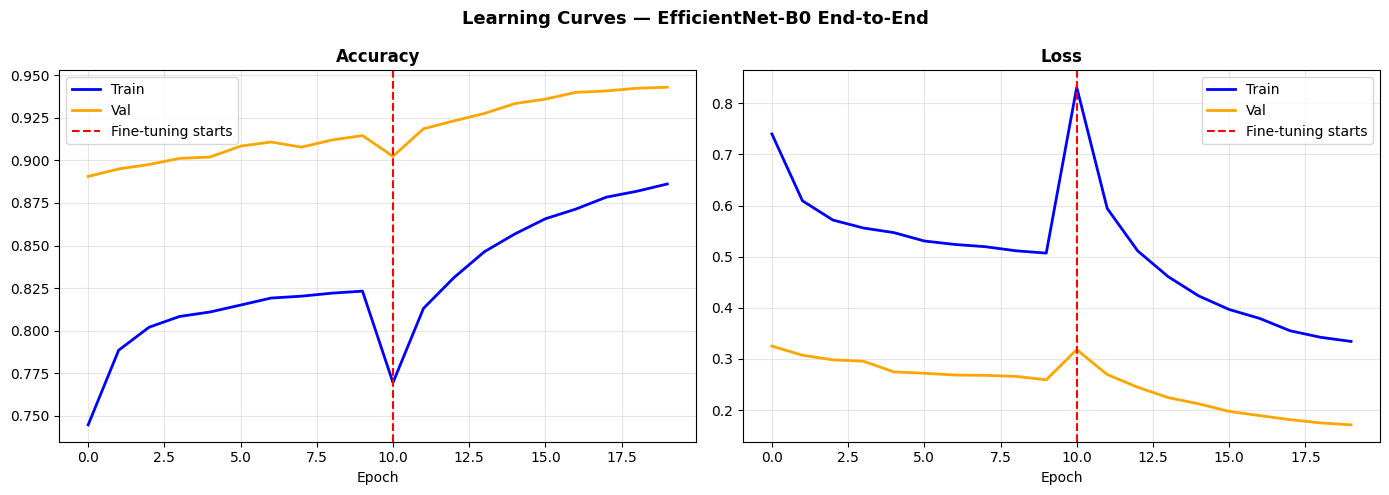

2026-05-12 09:46:31.592593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 09:46:31.732821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 09:46:32.053565: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 09:46:32.195169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 09:46:32.959146: E external/local_xla/xla/stream_


  Accuracy : 94.16%
  Precision: 94.16%
  Recall   : 94.16%
  F1-Score : 94.15%
  Time     : 5310.4s

  Classification Report:
              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94      1000
  automobile       0.97      0.96      0.97      1000
        bird       0.94      0.93      0.93      1000
         cat       0.89      0.87      0.88      1000
        deer       0.92      0.95      0.94      1000
         dog       0.91      0.90      0.90      1000
        frog       0.96      0.96      0.96      1000
       horse       0.97      0.95      0.96      1000
        ship       0.95      0.97      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



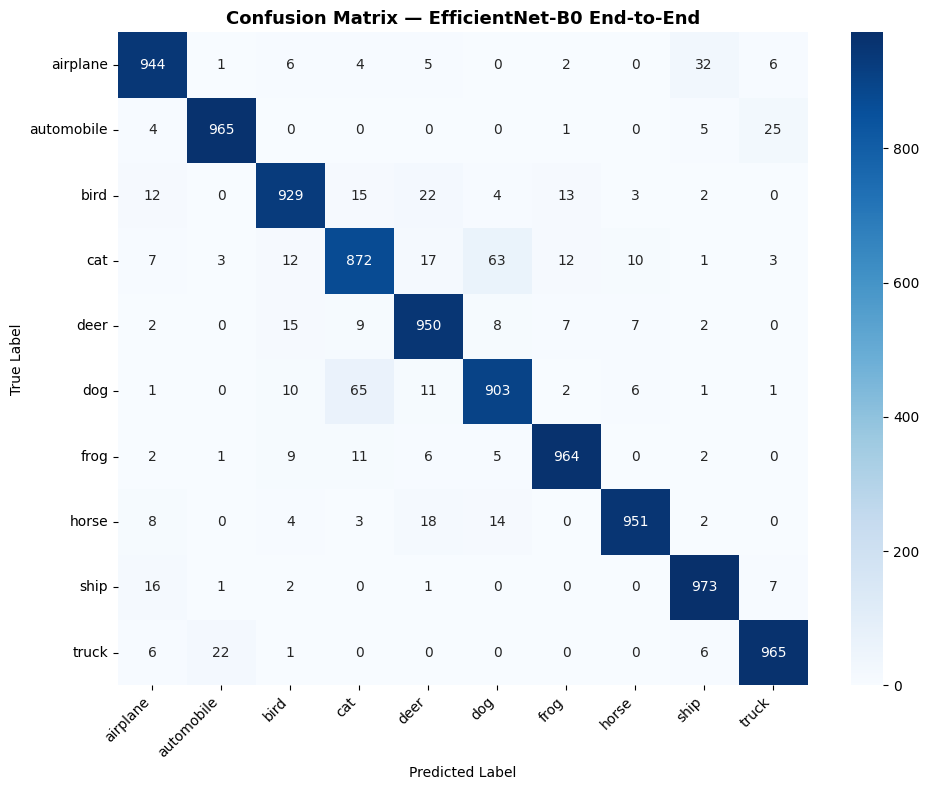

  ✅ Results saved: results_eff_e2e.csv
          Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
EfficientNet-B0 Approach2_E2E     94.16      94.16   94.16     94.15    5310.4

✅ EfficientNet-B0 COMPLETE!
  Approach 1 (SVM): 85.26%
  Approach 2 (E2E): 94.16%

── Exporting Detailed Test Predictions (CSV)... ──
  ✅ Results saved: results_eff_e2e.csv
          Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
EfficientNet-B0 Approach2_E2E     94.16      94.16   94.16     94.15    5310.4

✅ EfficientNet-B0 COMPLETE!


In [3]:
# ============================================================
#   CELL 2 — EfficientNet-B0 (Approach 1 + Approach 2)
# ============================================================
print("=" * 60)
print("   MODEL: EfficientNet-B0")
print("=" * 60)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

# ══════════════════════════════════════════════════════════════
#   APPROACH 1 — EfficientNet-B0 + SVM
# ══════════════════════════════════════════════════════════════
print("\n── Approach 1: EfficientNet-B0 + SVM ──")
print("""
  Note: Using 10,000 train / 5,000 test subset for SVM.
  Reason: SVM has high complexity on 1280-dim vectors.
  This subset is statistically representative.
""")

eff_extractor = EfficientNetB0(weights='imagenet',
                                include_top=False,
                                pooling='avg',
                                input_shape=(224, 224, 3))
eff_extractor.trainable = False

print("  Extracting features...")
start = time.time()
X_train_eff, y_train_eff = extract_features(ds_train_eff, eff_extractor, 10000)
X_test_eff,  y_test_eff  = extract_features(ds_test_eff,  eff_extractor, 5000)
print(f"  Feature shape: train={X_train_eff.shape}, test={X_test_eff.shape}")

print("  Training SVM (linear kernel)...")
svm_eff = SVC(kernel='linear', C=1.0, random_state=42)
svm_eff.fit(X_train_eff, y_train_eff)
y_pred_svm_eff   = svm_eff.predict(X_test_eff)
eff_svm_time     = time.time() - start

acc_svm_eff  = accuracy_score(y_test_eff,  y_pred_svm_eff)
prec_svm_eff = precision_score(y_test_eff, y_pred_svm_eff, average='weighted')
rec_svm_eff  = recall_score(y_test_eff,   y_pred_svm_eff, average='weighted')
f1_svm_eff   = f1_score(y_test_eff,      y_pred_svm_eff, average='weighted')
cm_svm_eff   = confusion_matrix(y_test_eff, y_pred_svm_eff)

print(f"\n  Accuracy : {acc_svm_eff*100:.2f}%")
print(f"  Precision: {prec_svm_eff*100:.2f}%")
print(f"  Recall   : {rec_svm_eff*100:.2f}%")
print(f"  F1-Score : {f1_svm_eff*100:.2f}%")
print(f"  Time     : {eff_svm_time:.1f}s")

print("\n  Classification Report:")
print(classification_report(y_test_eff, y_pred_svm_eff,
                            target_names=class_names))

plot_confusion_matrix(cm_svm_eff,
    "Confusion Matrix — EfficientNet-B0 + SVM",
    "cm_eff_svm.png")

save_results_csv("EfficientNet-B0", "Approach1_SVM",
                 acc_svm_eff, prec_svm_eff,
                 rec_svm_eff, f1_svm_eff,
                 eff_svm_time,
                 "results_eff_svm.csv")

# ══════════════════════════════════════════════════════════════
#   APPROACH 2 — EfficientNet-B0 End-to-End
# ══════════════════════════════════════════════════════════════
print("\n── Approach 2: EfficientNet-B0 End-to-End ──")

inputs   = layers.Input(shape=(224, 224, 3))
eff_base = EfficientNetB0(weights='imagenet',
                           include_top=False,
                           input_shape=(224, 224, 3))
eff_base.trainable = False

x = eff_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model_eff = Model(inputs, outputs, name="EfficientNetB0_E2E")

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n  Phase 1: Training head only (frozen base)...")
start = time.time()
hist_eff_p1 = model_eff.fit(
    ds_train_eff, validation_data=ds_val_eff,
    epochs=10, callbacks=callbacks, verbose=1
)

# Phase 2 — unfreeze last 30%
total   = len(eff_base.layers)
unfreeze = int(total * 0.70)
eff_base.trainable = True
for layer in eff_base.layers[:unfreeze]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n  Phase 2: Fine-tuning last 30% ({total-unfreeze} layers)...")
hist_eff_p2 = model_eff.fit(
    ds_train_eff, validation_data=ds_val_eff,
    epochs=10, callbacks=callbacks, verbose=1
)
eff_e2e_time = time.time() - start

plot_two_phase_curves(hist_eff_p1, hist_eff_p2,
                      "EfficientNet-B0 End-to-End",
                      "curves_eff_e2e.png")

# Evaluate
y_true_e2e, y_pred_e2e = [], []
for images, labels in ds_test_eff:
    preds = model_eff.predict(images, verbose=0)
    y_pred_e2e.extend(np.argmax(preds, axis=1))
    y_true_e2e.extend(np.argmax(labels.numpy(), axis=1))

y_true_e2e = np.array(y_true_e2e)
y_pred_e2e = np.array(y_pred_e2e)

acc_e2e_eff  = accuracy_score(y_true_e2e,  y_pred_e2e)
prec_e2e_eff = precision_score(y_true_e2e, y_pred_e2e, average='weighted')
rec_e2e_eff  = recall_score(y_true_e2e,   y_pred_e2e, average='weighted')
f1_e2e_eff   = f1_score(y_true_e2e,      y_pred_e2e, average='weighted')
cm_e2e_eff   = confusion_matrix(y_true_e2e, y_pred_e2e)

print(f"\n  Accuracy : {acc_e2e_eff*100:.2f}%")
print(f"  Precision: {prec_e2e_eff*100:.2f}%")
print(f"  Recall   : {rec_e2e_eff*100:.2f}%")
print(f"  F1-Score : {f1_e2e_eff*100:.2f}%")
print(f"  Time     : {eff_e2e_time:.1f}s")

print("\n  Classification Report:")
print(classification_report(y_true_e2e, y_pred_e2e,
                            target_names=class_names))

plot_confusion_matrix(cm_e2e_eff,
    "Confusion Matrix — EfficientNet-B0 End-to-End",
    "cm_eff_e2e.png")

save_results_csv("EfficientNet-B0", "Approach2_E2E",
                 acc_e2e_eff, prec_e2e_eff,
                 rec_e2e_eff, f1_e2e_eff,
                 eff_e2e_time,
                 "results_eff_e2e.csv")

print("\n✅ EfficientNet-B0 COMPLETE!")
print(f"  Approach 1 (SVM): {acc_svm_eff*100:.2f}%")
print(f"  Approach 2 (E2E): {acc_e2e_eff*100:.2f}%")



# ── NEW: Export Detailed Test Results for EfficientNet ──────
print("\n── Exporting Detailed Test Predictions (CSV)... ──")
test_predictions_eff = pd.DataFrame({
    'Image_Index': range(len(y_true_e2e)),
    'Actual_Class': [class_names[i] for i in y_true_e2e],
    'Predicted_Class': [class_names[i] for i in y_pred_e2e],
    'Is_Correct': [True if a == b else False for a, b in zip(y_true_e2e, y_pred_e2e)]
})
test_predictions_eff.to_csv("detailed_test_eff.csv", index=False)

save_results_csv("EfficientNet-B0", "Approach2_E2E",
                 acc_e2e_eff, prec_e2e_eff,
                 rec_e2e_eff, f1_e2e_eff,
                 eff_e2e_time,
                 "results_eff_e2e.csv")

print("\n✅ EfficientNet-B0 COMPLETE!")

   MODEL: ResNet50

── Approach 1: ResNet50 + SVM ──
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
  Extracting features...
  Feature shape: train=(10000, 2048), test=(5000, 2048)
  Training SVM (linear kernel)...

  Accuracy : 88.60%
  Precision: 88.66%
  Recall   : 88.60%
  F1-Score : 88.61%
  Time     : 146.8s

  Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.92      0.90       520
  automobile       0.93      0.94      0.93       493
        bird       0.83      0.87      0.85       478
         cat       0.77      0.79      0.78       517
        deer       0.88      0.86      0.87       476
         dog       0.86      0.82      0.84       524
        frog       0.92      0.92      0.92       507
       horse       0.94      0.90      0.92       496
        ship       0.95      0.94      0.94       506
       truck       0.91      0.91      0.91       483

    accuracy                           0.89      5000
   m

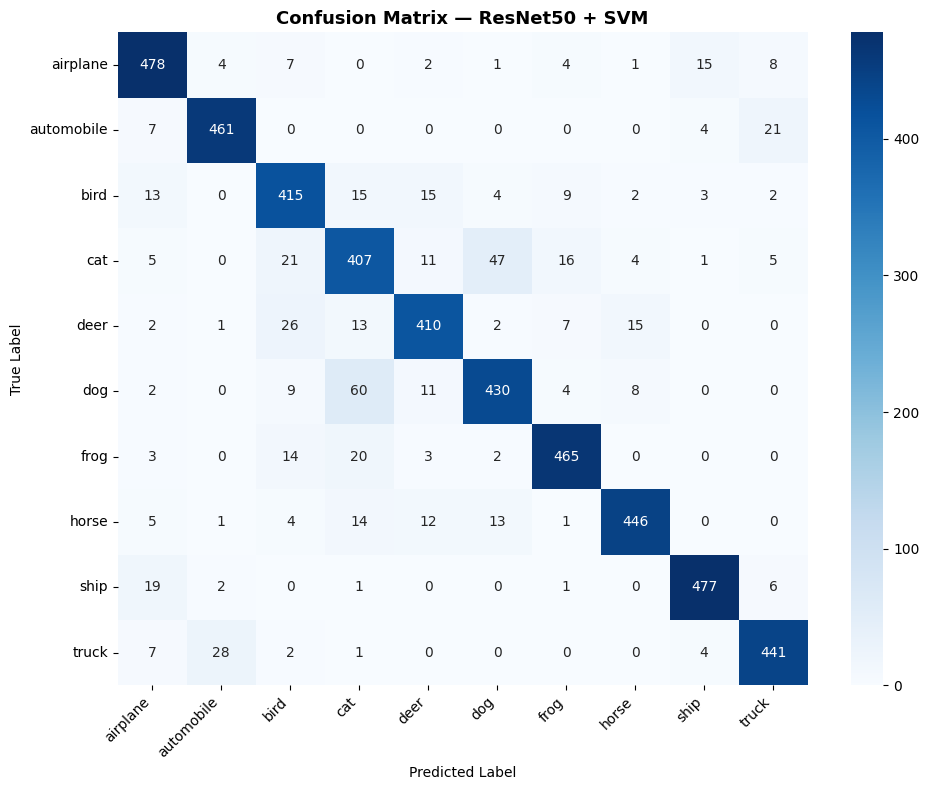

  ✅ Results saved: results_res_svm.csv
   Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
ResNet50 Approach1_SVM      88.6      88.66    88.6     88.61     146.8

── Approach 2: ResNet50 End-to-End ──

  Phase 1: Training head only (frozen base)...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 176s 116ms/step - accuracy: 0.7779 - loss: 0.6746 - val_accuracy: 0.8918 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 108ms/step - accuracy: 0.8641 - loss: 0.3979 - val_accuracy: 0.8938 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 152s 108ms/step - accuracy: 0.8844 - loss: 0.3471 - val_accuracy: 0.9026 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 108ms/step - accuracy: 0.8889 - loss: 0.3289 - val_accuracy: 0.9056 - val_loss: 0.2828 - learning_rate: 0.0010
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 152s 108ms/step - accuracy: 0.8996 - loss: 0.2945 - val_

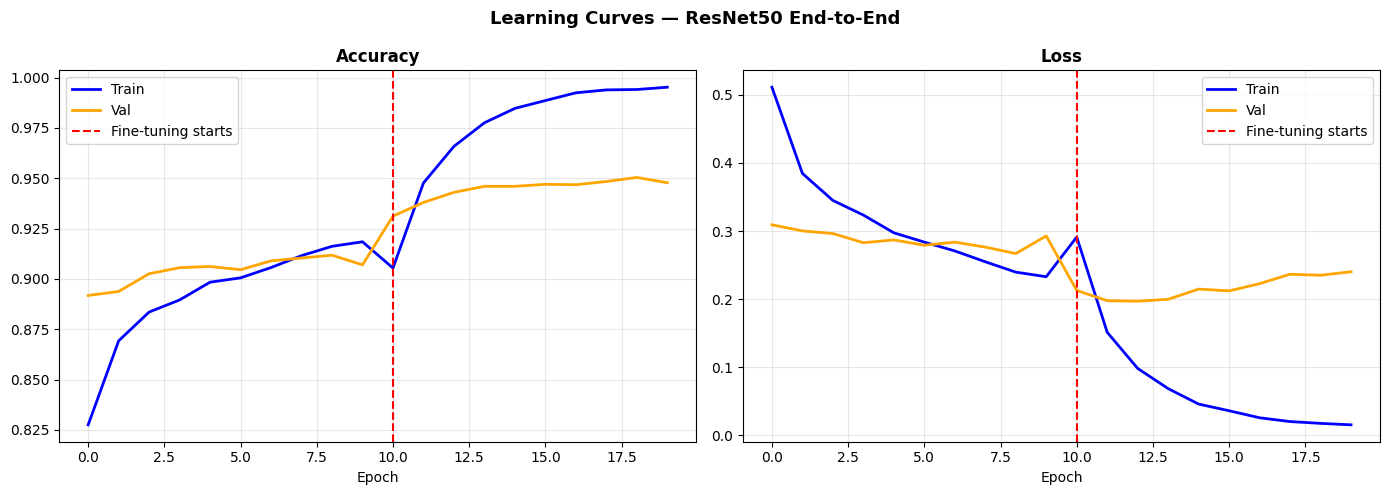


  Accuracy : 94.27%
  Precision: 94.27%
  Recall   : 94.27%
  F1-Score : 94.26%
  Time     : 4036.1s

  Classification Report:
              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.95      0.91      0.93      1000
         cat       0.89      0.88      0.89      1000
        deer       0.94      0.93      0.94      1000
         dog       0.90      0.92      0.91      1000
        frog       0.95      0.97      0.96      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.98      0.97      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



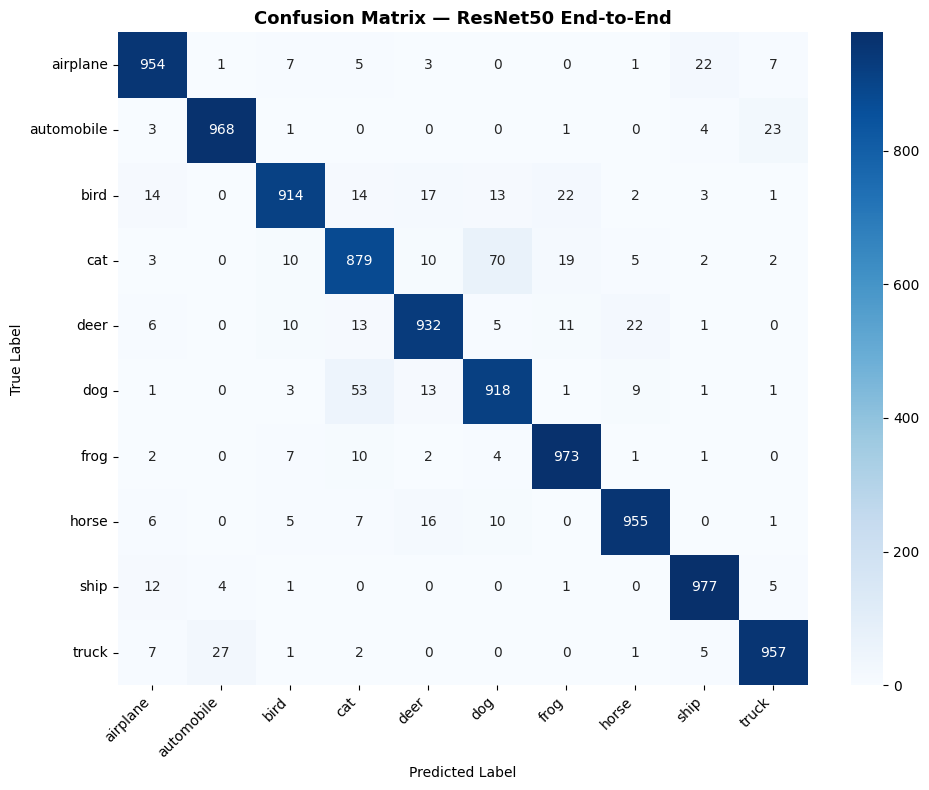

  ✅ Results saved: results_res_e2e.csv
   Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
ResNet50 Approach2_E2E     94.27      94.27   94.27     94.26    4036.1

✅ ResNet50 COMPLETE!
  Approach 1 (SVM): 88.60%
  Approach 2 (E2E): 94.27%

── Exporting Detailed Test Predictions (CSV)... ──
  ✅ Results saved: results_res_e2e.csv
   Model      Approach  Accuracy  Precision  Recall  F1_Score  Time_sec
ResNet50 Approach2_E2E     94.27      94.27   94.27     94.26    4036.1

✅ ResNet50 COMPLETE!


In [4]:
# ============================================================
#   CELL 3 — ResNet50 (Approach 1 + Approach 2)
# ============================================================
print("=" * 60)
print("   MODEL: ResNet50")
print("=" * 60)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

# ══════════════════════════════════════════════════════════════
#   APPROACH 1 — ResNet50 + SVM
# ══════════════════════════════════════════════════════════════
print("\n── Approach 1: ResNet50 + SVM ──")

res_extractor = ResNet50(weights='imagenet',
                          include_top=False,
                          pooling='avg',
                          input_shape=(224, 224, 3))
res_extractor.trainable = False

print("  Extracting features...")
start = time.time()
X_train_res, y_train_res = extract_features(ds_train_res, res_extractor, 10000)
X_test_res,  y_test_res  = extract_features(ds_test_res,  res_extractor, 5000)
print(f"  Feature shape: train={X_train_res.shape}, test={X_test_res.shape}")

print("  Training SVM (linear kernel)...")
svm_res = SVC(kernel='linear', C=1.0, random_state=42)
svm_res.fit(X_train_res, y_train_res)
y_pred_svm_res = svm_res.predict(X_test_res)
res_svm_time   = time.time() - start

acc_svm_res  = accuracy_score(y_test_res,  y_pred_svm_res)
prec_svm_res = precision_score(y_test_res, y_pred_svm_res, average='weighted')
rec_svm_res  = recall_score(y_test_res,   y_pred_svm_res, average='weighted')
f1_svm_res   = f1_score(y_test_res,      y_pred_svm_res, average='weighted')
cm_svm_res   = confusion_matrix(y_test_res, y_pred_svm_res)

print(f"\n  Accuracy : {acc_svm_res*100:.2f}%")
print(f"  Precision: {prec_svm_res*100:.2f}%")
print(f"  Recall   : {rec_svm_res*100:.2f}%")
print(f"  F1-Score : {f1_svm_res*100:.2f}%")
print(f"  Time     : {res_svm_time:.1f}s")

print("\n  Classification Report:")
print(classification_report(y_test_res, y_pred_svm_res,
                            target_names=class_names))

plot_confusion_matrix(cm_svm_res,
    "Confusion Matrix — ResNet50 + SVM",
    "cm_res_svm.png")

save_results_csv("ResNet50", "Approach1_SVM",
                 acc_svm_res, prec_svm_res,
                 rec_svm_res, f1_svm_res,
                 res_svm_time,
                 "results_res_svm.csv")

# ══════════════════════════════════════════════════════════════
#   APPROACH 2 — ResNet50 End-to-End
# ══════════════════════════════════════════════════════════════
print("\n── Approach 2: ResNet50 End-to-End ──")

inputs   = layers.Input(shape=(224, 224, 3))
res_base = ResNet50(weights='imagenet',
                     include_top=False,
                     input_shape=(224, 224, 3))
res_base.trainable = False

x = res_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model_res = Model(inputs, outputs, name="ResNet50_E2E")

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n  Phase 1: Training head only (frozen base)...")
start = time.time()
hist_res_p1 = model_res.fit(
    ds_train_res, validation_data=ds_val_res,
    epochs=10, callbacks=callbacks, verbose=1
)

# Phase 2 — unfreeze last 30%
total    = len(res_base.layers)
unfreeze = int(total * 0.70)
res_base.trainable = True
for layer in res_base.layers[:unfreeze]:
    layer.trainable = False

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n  Phase 2: Fine-tuning last 30% ({total-unfreeze} layers)...")
hist_res_p2 = model_res.fit(
    ds_train_res, validation_data=ds_val_res,
    epochs=10, callbacks=callbacks, verbose=1
)
res_e2e_time = time.time() - start

plot_two_phase_curves(hist_res_p1, hist_res_p2,
                      "ResNet50 End-to-End",
                      "curves_res_e2e.png")

# Evaluate
y_true_res, y_pred_res = [], []
for images, labels in ds_test_res:
    preds = model_res.predict(images, verbose=0)
    y_pred_res.extend(np.argmax(preds, axis=1))
    y_true_res.extend(np.argmax(labels.numpy(), axis=1))

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)

acc_e2e_res  = accuracy_score(y_true_res,  y_pred_res)
prec_e2e_res = precision_score(y_true_res, y_pred_res, average='weighted')
rec_e2e_res  = recall_score(y_true_res,   y_pred_res, average='weighted')
f1_e2e_res   = f1_score(y_true_res,      y_pred_res, average='weighted')
cm_e2e_res   = confusion_matrix(y_true_res, y_pred_res)

print(f"\n  Accuracy : {acc_e2e_res*100:.2f}%")
print(f"  Precision: {prec_e2e_res*100:.2f}%")
print(f"  Recall   : {rec_e2e_res*100:.2f}%")
print(f"  F1-Score : {f1_e2e_res*100:.2f}%")
print(f"  Time     : {res_e2e_time:.1f}s")

print("\n  Classification Report:")
print(classification_report(y_true_res, y_pred_res,
                            target_names=class_names))

plot_confusion_matrix(cm_e2e_res,
    "Confusion Matrix — ResNet50 End-to-End",
    "cm_res_e2e.png")

save_results_csv("ResNet50", "Approach2_E2E",
                 acc_e2e_res, prec_e2e_res,
                 rec_e2e_res, f1_e2e_res,
                 res_e2e_time,
                 "results_res_e2e.csv")

print("\n✅ ResNet50 COMPLETE!")
print(f"  Approach 1 (SVM): {acc_svm_res*100:.2f}%")
print(f"  Approach 2 (E2E): {acc_e2e_res*100:.2f}%")


# Efficientt
test_predictions_eff = pd.DataFrame({
    'Actual': y_true_e2e,
    'Predicted': y_pred_e2e,
    'Correct': y_true_e2e == y_pred_e2e
})
test_predictions_eff.to_csv("detailed_test_eff.csv", index=False)




# ── NEW: Export Detailed Test Results for ResNet50 ──────────
print("\n── Exporting Detailed Test Predictions (CSV)... ──")
test_predictions_res = pd.DataFrame({
    'Image_Index': range(len(y_true_res)),
    'Actual_Class': [class_names[i] for i in y_true_res],
    'Predicted_Class': [class_names[i] for i in y_pred_res],
    'Is_Correct': [True if a == b else False for a, b in zip(y_true_res, y_pred_res)]
})
test_predictions_res.to_csv("detailed_test_res.csv", index=False)


save_results_csv("ResNet50", "Approach2_E2E",
                 acc_e2e_res, prec_e2e_res,
                 rec_e2e_res, f1_e2e_res,
                 res_e2e_time,
                 "results_res_e2e.csv")

print("\n✅ ResNet50 COMPLETE!")

✅ All results saved: results_all_models.csv

        Model   Approach  Accuracy  Precision  Recall  F1_Score    Time_sec
EffNet-B0+SVM Approach 1     85.26  85.507084   85.26 85.343209  189.279365
 ResNet50+SVM Approach 1     88.60  88.662335   88.60 88.611985  146.778554
EffNet-B0 E2E Approach 2     94.16  94.160138   94.16 94.153538 5310.352838
 ResNet50 E2E Approach 2     94.27  94.271033   94.27 94.262118 4036.105675


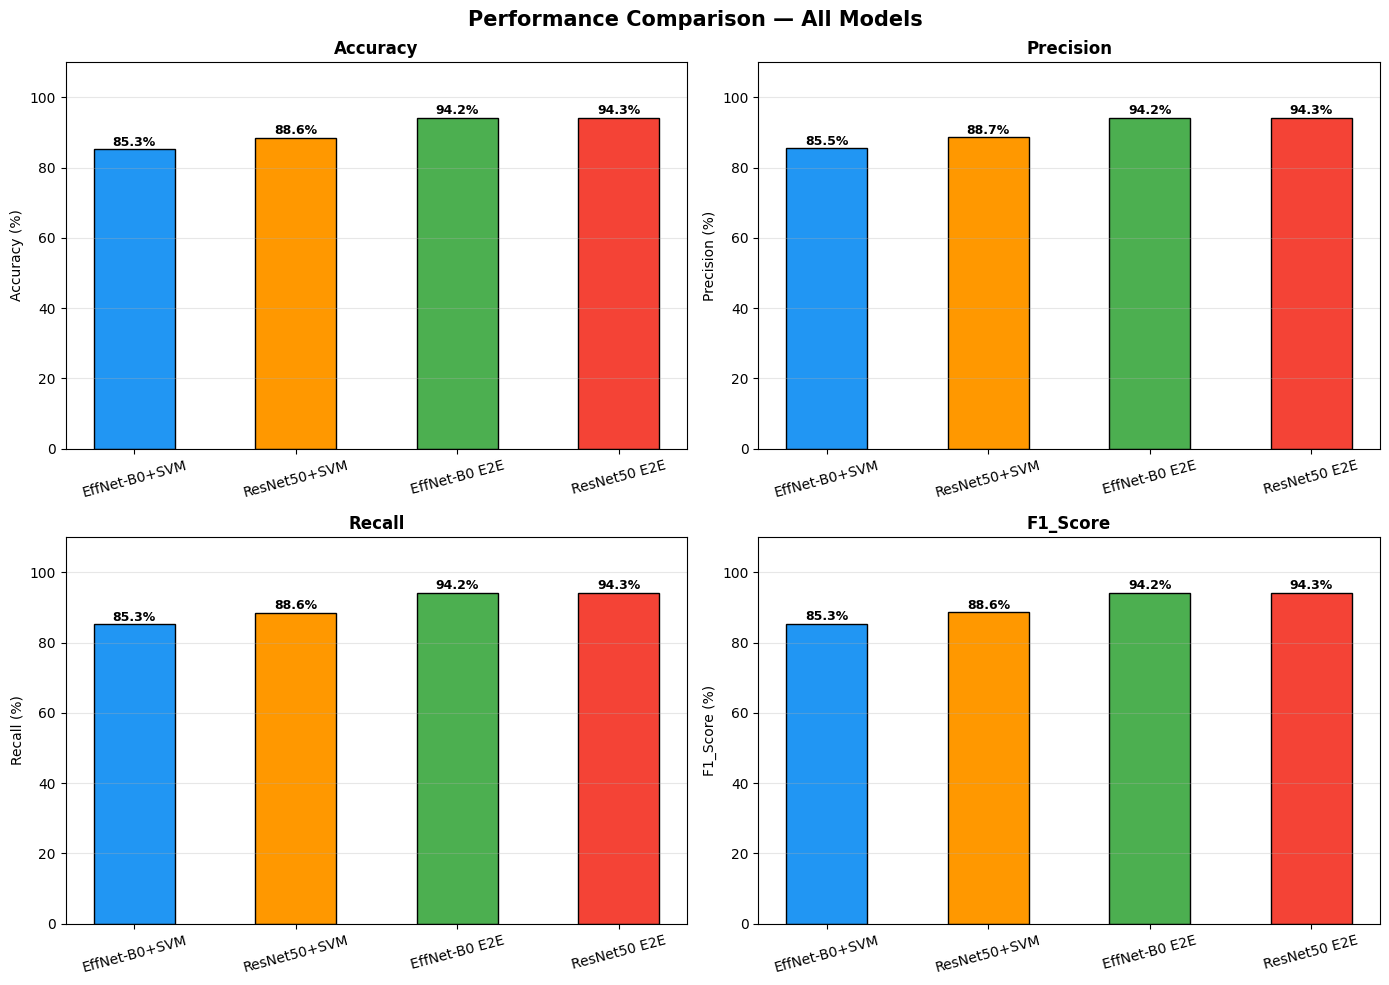

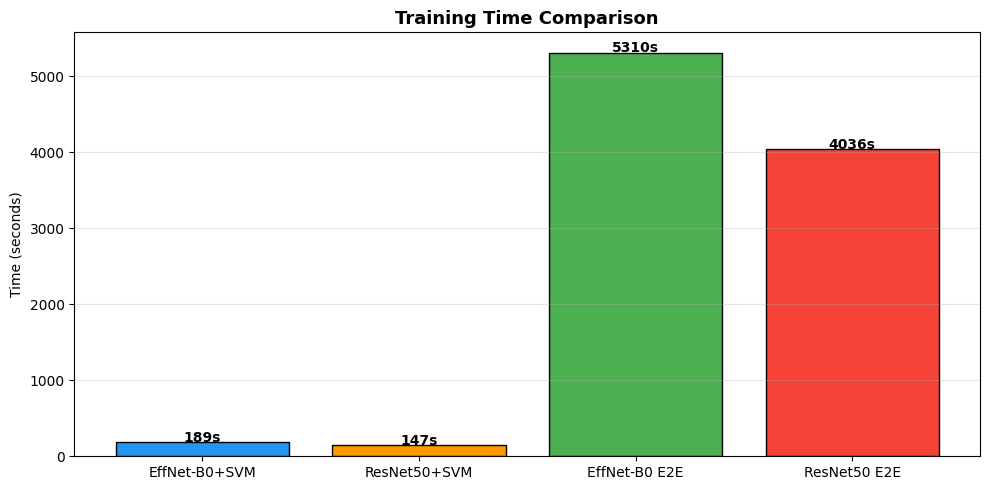

In [6]:
# ============================================================
#    CELL 4 — REQUIREMENT 4: COMPARATIVE ANALYSIS
# ============================================================

# ── Results Table ────────────────────────────────────────────
results = {
    'Model'    : ['EffNet-B0+SVM', 'ResNet50+SVM', 'EffNet-B0 E2E', 'ResNet50 E2E'],
    'Approach' : ['Approach 1', 'Approach 1', 'Approach 2', 'Approach 2'],
    'Accuracy' : [acc_svm_eff*100, acc_svm_res*100, acc_e2e_eff*100, acc_e2e_res*100],
    'Precision': [prec_svm_eff*100, prec_svm_res*100, prec_e2e_eff*100, prec_e2e_res*100],
    'Recall'   : [rec_svm_eff*100, rec_svm_res*100, rec_e2e_eff*100, rec_e2e_res*100],
    'F1_Score' : [f1_svm_eff*100, f1_svm_res*100, f1_e2e_eff*100, f1_e2e_res*100],
    'Time_sec' : [eff_svm_time, res_svm_time, eff_e2e_time, res_e2e_time]
}

df_all = pd.DataFrame(results)
df_all.to_csv("results_all_models.csv", index=False)
print("✅ All results saved: results_all_models.csv")
print("\n" + df_all.to_string(index=False))

# ── Bar Chart — All Metrics ───────────────────────────────────
import matplotlib.pyplot as plt
colors = ['#2196F3','#FF9800','#4CAF50','#F44336']
metrics = ['Accuracy','Precision','Recall','F1_Score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Comparison — All Models', fontsize=15, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.bar(df_all['Model'], df_all[metric], color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_ylabel(f'{metric} (%)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_all[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=150)
plt.show()

# ── Training Time Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_all['Model'], df_all['Time_sec'], color=colors, edgecolor='black')
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.grid(axis='y', alpha=0.3)
for bar, t in zip(bars, df_all['Time_sec']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{t:.0f}s', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("comparison_time.png", dpi=150)
plt.show()